<a href="https://colab.research.google.com/github/Parth-git7/skincare-product-growth-predictor/blob/main/SkinCare_model_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn==1.9.0 numpy==2.5.0 pandas==3.0.3 joblib==1.5.3 scipy==1.18.0

In [2]:
# ── Cell 1: Load Dataset ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np

df = pd.read_excel('/content/skincare_1000_clean.xlsx', sheet_name='Dataset')

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(1000, 19)
  Product_type Product_name     Brand  Years_in_market  Medically_approved  \
0    Sunscreen    Product_1      Plum               11                   0   
1    Sunscreen    Product_2  Re'equil               10                   1   
2    Sunscreen    Product_3    CeraVe               15                   1   
3    Sunscreen    Product_4  Himalaya               40                   1   
4    Sunscreen    Product_5   Sebamed               55                   1   

   avg_rating_other_products  Fragrance  Price_per_ml  packaging_score  \
0                      3.961          0          3.58              7.5   
1                      4.293          0          5.07              8.9   
2                      4.476          0          8.35              8.3   
3                      4.291          0          3.09              8.6   
4                      4.542          0          5.36              8.3   

   Nykaa_ratings  Flipkart_ratings  amazon_ratings  Sensitive  Oily  Normal

In [3]:
# ── Cell 2: Define Targets ────────────────────────────────────────────────────

# Target 1: Average Rating (Regression target)
df['avg_rating'] = (df['Nykaa_ratings'] + df['Flipkart_ratings'] + df['amazon_ratings']) / 3

# Target 2: Market Performance Class (Classification target)
# FIX: Classify on avg_rating (corr ~0.60 with features) NOT Rating_count (corr ~0.01)
# Rating_count is purely a popularity metric — features cannot predict it, causing 0% High recall
# avg_rating reflects actual product quality captured by the features

p33 = df['avg_rating'].quantile(0.33)
p66 = df['avg_rating'].quantile(0.66)

def classify_performance(rating):
    if rating > p66:    return 'High'
    elif rating >= p33: return 'Medium'
    else:               return 'Low'

df['market_class'] = df['avg_rating'].apply(classify_performance)

print(f"Thresholds — Low: < {p33:.2f} | Medium: {p33:.2f}–{p66:.2f} | High: > {p66:.2f}")
print()
print(df['avg_rating'].describe())
print()
print(df['market_class'].value_counts())

Thresholds — Low: < 3.93 | Medium: 3.93–4.40 | High: > 4.40

count    1000.000000
mean        4.170500
std         0.448063
min         3.133333
25%         3.800000
50%         4.166667
75%         4.533333
max         4.966667
Name: avg_rating, dtype: float64

market_class
Medium    351
High      328
Low       321
Name: count, dtype: int64


In [4]:
# ── Cell 3: Brand Score ───────────────────────────────────────────────────────

# Normalize avg_rating_other_products and Years_in_market to 0–1
df['Rating_normalized'] = (df['avg_rating_other_products'] - df['avg_rating_other_products'].min()) / \
                           (df['avg_rating_other_products'].max() - df['avg_rating_other_products'].min())

df['Years_normalized']  = (df['Years_in_market'] - df['Years_in_market'].min()) / \
                           (df['Years_in_market'].max() - df['Years_in_market'].min())

# Brand Score formula
df['Brand_score'] = (df['Rating_normalized'] * 0.75) + (df['Years_normalized'] * 0.25)

print(df.groupby('Brand')['Brand_score'].mean().sort_values(ascending=False))

Brand
La Roche-Posay       0.763449
Cetaphil             0.762572
Avene                0.733471
Neutrogena           0.726360
Sebamed              0.677154
CeraVe               0.671219
Bioderma             0.660451
Ponds                0.573773
Kaya                 0.571706
Dermafique           0.568662
The Ordinary         0.565186
Forest Essentials    0.554338
Fixderma             0.552944
Minimalist           0.544803
Deconstruct          0.532345
Garnier              0.530124
Nivea                0.528570
Re'equil             0.521463
Dot & Key            0.507689
Olay                 0.501788
Pilgrim              0.496648
Plum                 0.494315
Foxtale              0.483560
Lakme                0.480785
Himalaya             0.475612
Kama Ayurveda        0.475297
mCaffeine            0.470196
VLCC                 0.461594
Lotus Herbals        0.459501
Biotique             0.431503
WOW Skin Science     0.426220
Mamaearth            0.408407
Name: Brand_score, dtype: float64


In [5]:
# ── Cell 4: India-Specific Engineered Features ────────────────────────────────
# Oily skin dominates Indian climate; Sensitive skin predicts irritation
# Replaces dropped columns: Dry, Combination, Pigmentation_score

df['oily_sensitive_risk']  = df['Oily'] * df['Sensitive']          # Oily+Sensitive = highest irritation risk
df['sensitive_irritation'] = df['Sensitive'] * df['Causes_irritation']  # Key irritation predictor
df['oily_fragrance_risk']  = df['Oily'] * df['Fragrance']          # Fragrance on oily skin — common complaint

print("India-specific features added:")
print(df[['oily_sensitive_risk', 'sensitive_irritation', 'oily_fragrance_risk']].describe())

India-specific features added:
       oily_sensitive_risk  sensitive_irritation  oily_fragrance_risk
count          1000.000000           1000.000000          1000.000000
mean              0.315000              0.113000             0.154000
std               0.464748              0.316751             0.361129
min               0.000000              0.000000             0.000000
25%               0.000000              0.000000             0.000000
50%               0.000000              0.000000             0.000000
75%               1.000000              0.000000             0.000000
max               1.000000              1.000000             1.000000


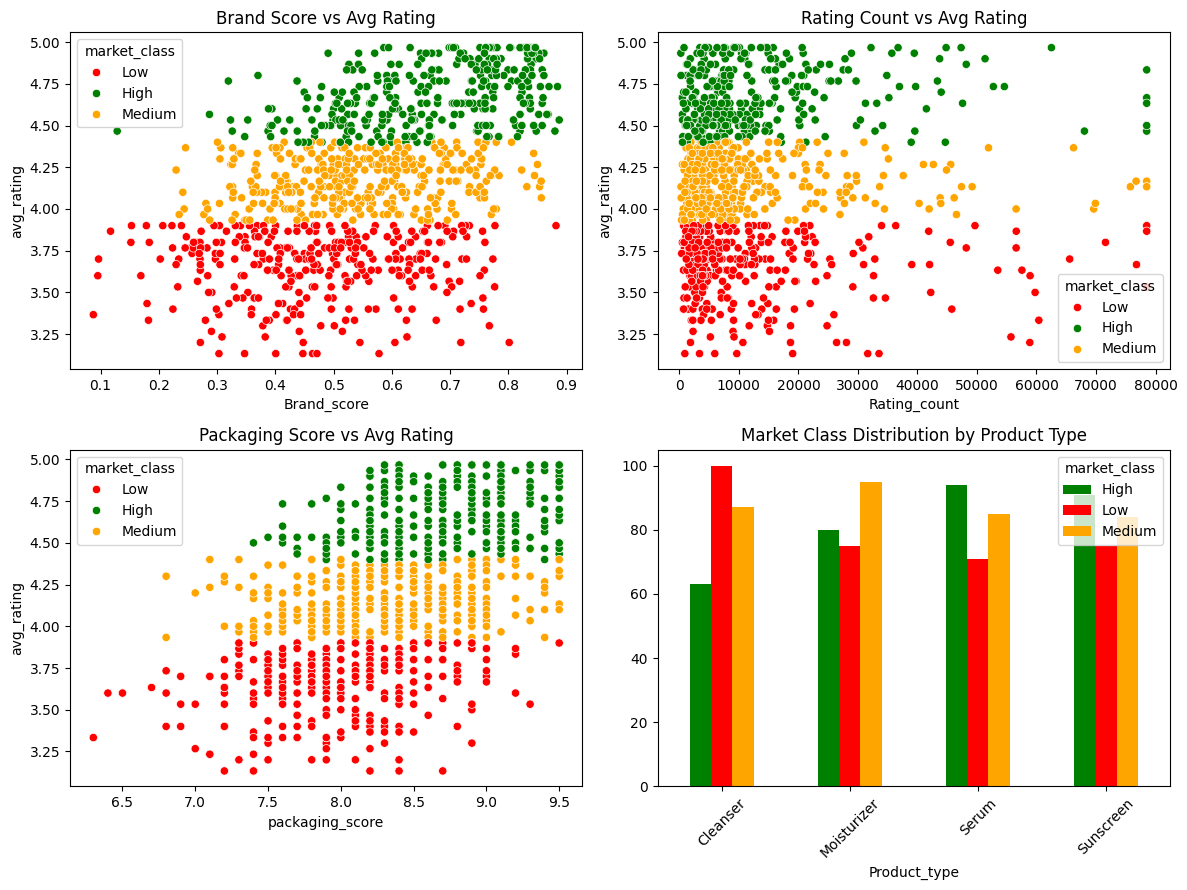

In [6]:
# ── Cell 5: EDA Visualisations ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
palette = {'High': 'green', 'Medium': 'orange', 'Low': 'red'}

# 1. Brand Score vs Avg Rating
sns.scatterplot(data=df, x='Brand_score', y='avg_rating',
                hue='market_class', ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('Brand Score vs Avg Rating')

# 2. Rating Count vs Avg Rating
sns.scatterplot(data=df, x='Rating_count', y='avg_rating',
                hue='market_class', ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('Rating Count vs Avg Rating')

# 3. Packaging Score vs Avg Rating
sns.scatterplot(data=df, x='packaging_score', y='avg_rating',
                hue='market_class', ax=axes[1, 0], palette=palette)
axes[1, 0].set_title('Packaging Score vs Avg Rating')

# 4. Market Class Distribution by Product Type
df.groupby(['Product_type', 'market_class']).size().unstack().plot(
    kind='bar', ax=axes[1, 1],
    color=['green', 'red', 'orange'])
axes[1, 1].set_title('Market Class Distribution by Product Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# ── Cell 6: Feature Preparation ───────────────────────────────────────────────

# One-hot encode Product_type
df = pd.get_dummies(df, columns=['Product_type'], drop_first=False)

# UPDATED feature list:
#   ADDED    → oily_sensitive_risk, sensitive_irritation, oily_fragrance_risk
features = [
    'Brand_score',
    'Hydration_score',
    'Medically_approved',
    'Causes_irritation',
    'packaging_score',
    'Fragrance',
    'Sensitive',
    'Oily',
    'Normal',
    'Price_per_ml',
    'oily_sensitive_risk',
    'sensitive_irritation',
    'oily_fragrance_risk',
    'Product_type_Cleanser',
    'Product_type_Moisturizer',
    'Product_type_Serum',
    'Product_type_Sunscreen'
]

X        = df[features]
y_class  = df['market_class']   # Classification target
y_rating = df['avg_rating']     # Regression target

print(X.shape)
print(X.head())
print()
print(y_class.value_counts())

(1000, 17)
   Brand_score  Hydration_score  Medically_approved  Causes_irritation  \
0     0.151963                3                   0                  0   
1     0.467295                5                   1                  0   
2     0.649223                8                   1                  0   
3     0.509246                5                   1                  0   
4     0.770680                4                   1                  1   

   packaging_score  Fragrance  Sensitive  Oily  Normal  Price_per_ml  \
0              7.5          0          0     1       0          3.58   
1              8.9          0          1     1       0          5.07   
2              8.3          0          0     1       0          8.35   
3              8.6          0          1     0       1          3.09   
4              8.3          0          1     0       1          5.36   

   oily_sensitive_risk  sensitive_irritation  oily_fragrance_risk  \
0                    0                    

In [8]:
# ── Cell 7: Train/Test Split + Scaling ───────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_class_train, y_class_test, y_rating_train, y_rating_test = train_test_split(
    X, y_class, y_rating, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train_scaled.shape[0]}')
print(f'Testing samples  : {X_test_scaled.shape[0]}')
print(f'\nClass distribution in train:\n{y_class_train.value_counts()}')
print(f'\nClass distribution in test:\n{y_class_test.value_counts()}')

Training samples : 800
Testing samples  : 200

Class distribution in train:
market_class
Medium    281
High      262
Low       257
Name: count, dtype: int64

Class distribution in test:
market_class
Medium    70
High      66
Low       64
Name: count, dtype: int64


In [9]:
# ── Cell 8: Models — Gradient Boosting ───────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score

# Model 1: Classification — Gradient Boosting
clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_class_train)

# Model 2: Regression — Gradient Boosting
reg = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
reg.fit(X_train_scaled, y_rating_train)

# Evaluate Classification
y_class_pred = clf.predict(X_test_scaled)
print("=== Classification Report ===")
print(classification_report(y_class_test, y_class_pred))

# Evaluate Regression
y_rating_pred = reg.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_rating_test, y_rating_pred))
r2   = r2_score(y_rating_test, y_rating_pred)
print("=== Regression Report ===")
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.85      0.86      0.86        66
         Low       0.83      0.81      0.82        64
      Medium       0.70      0.70      0.70        70

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200

=== Regression Report ===
RMSE : 0.1669
R2   : 0.8633


5-Fold CV F1 (Weighted): 0.7634 ± 0.0311

Class distribution:
market_class
Medium    351
High      328
Low       321
Name: count, dtype: int64

Correlation with avg_rating:
                      avg_rating
avg_rating              1.000000
packaging_score         0.553084
Price_per_ml            0.535478
Brand_score             0.501648
Hydration_score         0.111212
oily_sensitive_risk     0.020794
oily_fragrance_risk    -0.215843
sensitive_irritation   -0.278594

Top 10 Feature Importances (Classification):
Price_per_ml            0.207410
Brand_score             0.203782
Medically_approved      0.187092
packaging_score         0.142503
Causes_irritation       0.092672
Fragrance               0.075753
Hydration_score         0.020717
sensitive_irritation    0.010576
Oily                    0.009829
Normal                  0.009295
dtype: float64


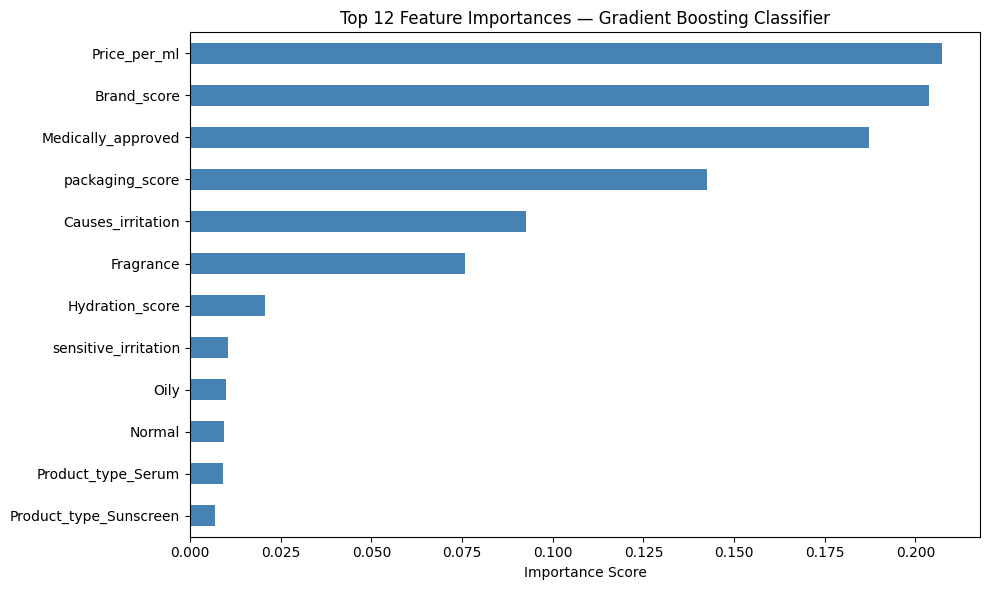

In [10]:
# ── Cell : Diagnostics & Feature Importance ─────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train_scaled, y_class_train,
                             cv=cv, scoring='f1_weighted')
print(f'5-Fold CV F1 (Weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Class distribution
print('\nClass distribution:')
print(df['market_class'].value_counts())

# Correlation of key features with avg_rating
print('\nCorrelation with avg_rating:')
corr_cols = ['Brand_score', 'Hydration_score', 'packaging_score', 'Price_per_ml',
             'oily_sensitive_risk', 'sensitive_irritation', 'oily_fragrance_risk', 'avg_rating']
print(df[corr_cols].corr()[['avg_rating']].sort_values('avg_rating', ascending=False))

# Feature importances
fi = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print('\nTop 10 Feature Importances (Classification):')
print(fi.head(10))

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
fi.head(12).plot(kind='barh', color='steelblue')
plt.title('Top 12 Feature Importances — Gradient Boosting Classifier')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
import sklearn
print(sklearn.__version__)

1.9.0


In [12]:
import numpy
print(numpy.__version__)

2.5.0


In [13]:
import joblib, pandas
print(joblib.__version__, pandas.__version__)
import sys
print(sys.version)

1.5.3 3.0.3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# ── FINAL CELL: Interactive Product Predictor ─────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
# Paste as the LAST cell. Requires: clf, reg, scaler, features, df
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

print("=" * 55)
print("       🧴 SKINCARE PRODUCT MARKET PREDICTOR")
print("=" * 55)

# ── Inputs (product attributes only) ─────────────────────────────────────────
product_name = input("\nProduct Name: ").strip() or "My Product"

print("\n── Skin Type (1 = Yes, 0 = No) ──")
sensitive  = int(input("  Sensitive : "))
oily       = int(input("  Oily      : "))
normal     = int(input("  Normal    : "))

print("\n── Product Details ──")
product_type   = input("  Type [Cleanser / Moisturizer / Serum / Sunscreen]: ").strip().capitalize()
price_per_ml   = float(input("  Price per ml (₹)        : "))
packaging      = float(input("  Packaging score (1–10)  : "))
hydration      = float(input("  Hydration score (1–10)  : "))
medically_appr = int(input("  Medically approved (1/0) : "))
causes_irrit   = int(input("  Causes irritation (1/0)  : "))
fragrance      = int(input("  Contains fragrance (1/0) : "))

print("\n── Brand Details ──")
avg_rating_brand = float(input("  Brand avg rating on other products (1–5) : "))
years_in_market  = int(input("  Brand years in market                     : "))


# ── Feature Engineering ───────────────────────────────────────────────────────
rating_norm = (avg_rating_brand - df['avg_rating_other_products'].min()) / \
              (df['avg_rating_other_products'].max() - df['avg_rating_other_products'].min())
years_norm  = (years_in_market  - df['Years_in_market'].min()) / \
              (df['Years_in_market'].max() - df['Years_in_market'].min())
brand_score = (rating_norm * 0.75) + (years_norm * 0.25)

input_features = pd.DataFrame([{
    'Brand_score'             : brand_score,
    'Hydration_score'         : hydration,
    'Medically_approved'      : medically_appr,
    'Causes_irritation'       : causes_irrit,
    'packaging_score'         : packaging,
    'Fragrance'               : fragrance,
    'Sensitive'               : sensitive,
    'Oily'                    : oily,
    'Normal'                  : normal,
    'Price_per_ml'            : price_per_ml,
    'oily_sensitive_risk'     : oily * sensitive,
    'sensitive_irritation'    : sensitive * causes_irrit,
    'oily_fragrance_risk'     : oily * fragrance,
    'Product_type_Cleanser'   : 1 if product_type == 'Cleanser'    else 0,
    'Product_type_Moisturizer': 1 if product_type == 'Moisturizer' else 0,
    'Product_type_Serum'      : 1 if product_type == 'Serum'       else 0,
    'Product_type_Sunscreen'  : 1 if product_type == 'Sunscreen'   else 0,
}])

# ── Model Predictions ─────────────────────────────────────────────────────────
input_scaled    = scaler.transform(input_features[features])
pred_rating     = round(reg.predict(input_scaled)[0], 2)       # regression  → avg rating
pred_class      = clf.predict(input_scaled)[0]                 # classifier  → High / Medium / Low
pred_confidence = round(max(clf.predict_proba(input_scaled)[0]) * 100, 1)


# ── 6-Category Verdict (pred_class + pred_rating combined) ───────────────────
def market_verdict(pred_class, rating):
    if   pred_class == "High"   and rating >= 4.2:
        return "🏆 TOP RANKER",          "Highly popular AND top rated. This product is a market leader."
    elif pred_class == "High"   and rating >= 3.8:
        return "👥 CROWD FAVOURITE",     "Will gain strong reach but ratings are average — good launch, needs quality improvement."
    elif pred_class == "High":
        return "📉 OVERHYPED – DECLINING","Will get attention but poor ratings will drive a fast decline."
    elif pred_class == "Medium" and rating >= 4.2:
          return "🚀 RISING STAR",         "Excellent quality with moderate reach. High growth potential with better marketing."
    elif pred_class == "Medium":
        return "✅ SOLID PERFORMER",      "Steady market presence with decent ratings. Reliable, not spectacular."
    else:
        if rating >= 4.2:
            return "💎 HIDDEN GEM",       "Quality is there but reach will be limited — needs strong marketing push."
        else:
            return "❌ POOR PRODUCT",     "Low popularity and low ratings predicted. Revisit formulation before launch."

verdict_label, verdict_desc = market_verdict(pred_class, pred_rating)


# ── Report ────────────────────────────────────────────────────────────────────
print("\n")
print("=" * 55)
print(f"  REPORT — {product_name.upper()}")
print("=" * 55)
print(f"\n  Predicted Avg Rating  :  {pred_rating} / 5.0")
print(f"  Predicted Popularity  :  {pred_class}  ({pred_confidence}% confidence)")
print(f"\n  Verdict  →  {verdict_label}")
print(f"  {verdict_desc}")
print("\n" + "=" * 55)

       🧴 SKINCARE PRODUCT MARKET PREDICTOR


KeyboardInterrupt: Interrupted by user

In [15]:
import joblib

joblib.dump(clf, "clf.pkl")
joblib.dump(reg, "reg.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']